2026-05-18 19:39:20.721476: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-18 19:39:20.730434: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-18 19:39:21.059013: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-18 19:39:23.648240: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off,



Corrupt fraction = 0%

Training: No reg


/home/laraf/jup-env/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-05-18 19:39:27.357449: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Train acc : 0.9489
Val acc   : 0.9070
Gap       : 0.0419

Training: L2 1e-4
Train acc : 0.9352
Val acc   : 0.9055
Gap       : 0.0297

Training: L2 1e-3
Train acc : 0.9284
Val acc   : 0.8960
Gap       : 0.0324

Training: L2 1e-2
Train acc : 0.9191
Val acc   : 0.9170
Gap       : 0.0021

Training: L1 1e-4
Train acc : 0.9227
Val acc   : 0.8975
Gap       : 0.0253

Training: L1 1e-3
Train acc : 0.9024
Val acc   : 0.8770
Gap       : 0.0254

Training: L1 1e-2
Train acc : 0.3717
Val acc   : 0.4070
Gap       : -0.0353

Training: Elastic 1e-4
Train acc : 0.9494
Val acc   : 0.9100
Gap       : 0.0394

Training: Elastic 1e-3
Train acc : 0.9034
Val acc   : 0.9110
Gap       : -0.0076


Corrupt fraction = 20%

Training: No reg
Train acc : 0.7322
Val acc   : 0.8320
Gap       : -0.0998

Training: L2 1e-4
Train acc : 0.7347
Val acc   : 0.8635
Gap       : -0.1288

Training: L2 1e-3
Train acc : 0.7195
Val acc   : 0.8160
Gap       : -0.0965

Training: L2 1e-2
Train acc : 0.6886
Val acc   : 0.8365
Gap       :

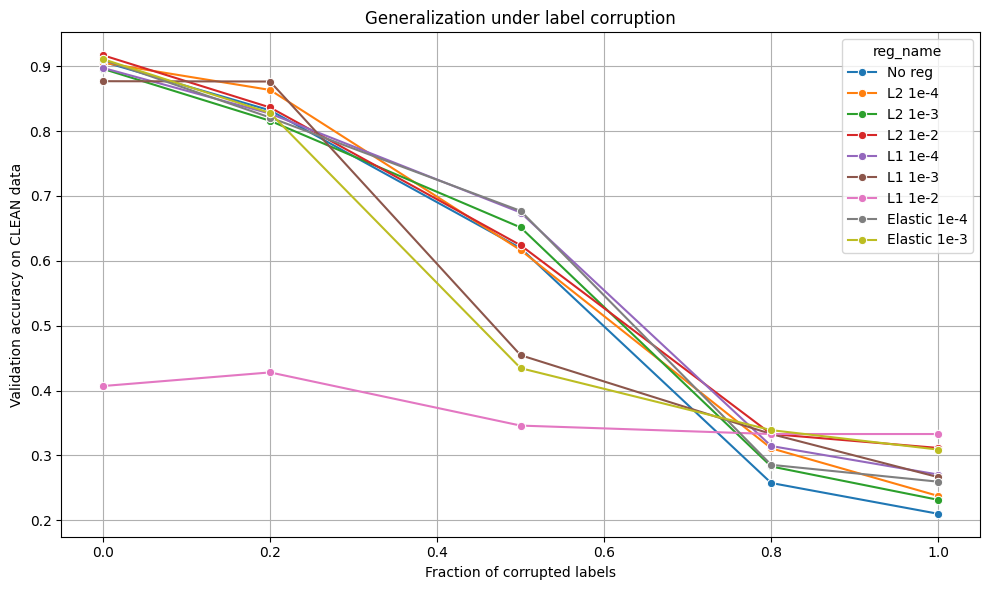

In [1]:
"""
Memorization / regularization experiment WITH SNR=10
----------------------------------------

Goal
-----
Train CNNs with different regularizers on datasets with partially
randomized labels, then evaluate ONLY on clean validation data.

This measures whether regularization helps the network:
    - learn the real sinusoidal signal
    - avoid memorizing corrupted labels

Inspired by:
Arpit et al. (2017)
"A Closer Look at Memorization in Deep Networks"
"""

import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D,
    MaxPooling1D,
    Flatten,
    Dense,
    Dropout
)

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# ============================================================
# Reproducibility
# ============================================================

np.random.seed(12345)
tf.random.set_seed(12345)

# ============================================================
# Signal generation helpers
# ============================================================

jump = lambda drift1, drift2, std1, std2: [
    int(np.random.normal(drift1, std1)),
    int(np.random.normal(drift2, std2))
]

def pattern(i, z1, z2, a1, a2):
    return [
        int(a1 * np.sin((np.pi * i) / z1)),
        int(a2 * np.sin((np.pi * i) / z2))
    ]

# ============================================================
# CNN model
# ============================================================

def build_model(
    L,
    l,
    r,
    n_class=3,
    kernel_size=11,
    NF=5,
    stddev=0.05
):

    input_shape = (L, 2)

    reg = None

    if l != 0:

        # L2
        if r == 2:
            reg = tf.keras.regularizers.l2(l)

        # L1
        elif r == 1:
            reg = tf.keras.regularizers.l1(l)

        # ElasticNet
        elif r == 0:
            reg = tf.keras.regularizers.L1L2(
                l1=l,
                l2=l
            )

    ini = tf.keras.initializers.RandomNormal(
        mean=0.0,
        stddev=stddev
    )

    model = Sequential([

        Conv1D(
            filters=NF,
            kernel_size=kernel_size,
            kernel_initializer=ini,
            kernel_regularizer=reg,
            padding='same',
            activation='relu',
            input_shape=input_shape
        ),

        MaxPooling1D(pool_size=2),

        Conv1D(
            filters=NF * 2,
            kernel_size=5,
            activation='relu',
            kernel_regularizer=reg
        ),

        MaxPooling1D(pool_size=2),

        Flatten(),

        Dense(
            32,
            activation='relu',
            kernel_regularizer=reg
        ),

        Dropout(0.2),

        Dense(
            n_class,
            activation='softmax'
        )
    ])

    model.compile(
        loss='categorical_crossentropy',
        optimizer=tf.keras.optimizers.Adam(),
        metrics=['accuracy']
    )

    return model

# ============================================================
# Dataset generation
# ============================================================

def generate_dataset(
    N,
    L,
    d,
    A1,
    A2,
    sigma,
    bias,
    n_class=3
):

    Z1 = Z2 = d

    x = np.zeros((N, L, 2), dtype=np.float32)

    y = np.zeros(N, dtype=np.int32)

    for i in range(N):

        # random walk initialization
        if i > 0:

            j0, j1 = jump(
                bias,
                bias,
                sigma,
                sigma
            )

            x[i][0][0] = x[i-1][-1][0] + j0
            x[i][0][1] = x[i-1][-1][1] + j1

        # random walk evolution
        for j in range(1, L):

            j0, j1 = jump(
                bias,
                bias,
                sigma,
                sigma
            )

            x[i][j][0] = x[i][j-1][0] + j0
            x[i][j][1] = x[i][j-1][1] + j1

        # classes: 0,1,2
        y[i] = i % n_class

        # insert sinusoidal pattern
        if y[i] > 0:

            j01, j02 = np.random.randint(
                0,
                L - 1 - d,
                2
            )

            sign = 3 - 2 * y[i]

            for j in range(d):

                p1, p2 = pattern(
                    j,
                    Z1,
                    Z2,
                    A1,
                    A2
                )

                x[i][j01 + j][0] += sign * p1
                x[i][j02 + j][1] += sign * p2

    # ========================================================
    # normalization
    # ========================================================

    xm = x.mean(axis=1, keepdims=True)

    xs = x.std(axis=1, keepdims=True) + 1e-8

    x = (x - xm) / xs

    # one-hot labels
    y_oh = np.eye(n_class)[y].astype(np.float32)

    return x, y_oh

# ============================================================
# Label corruption
# ============================================================

def corrupt_labels(
    y,
    corrupt_fraction,
    n_class=3
):

    y_corrupt = y.copy()

    N = len(y)

    n_corrupt = int(corrupt_fraction * N)

    corrupt_idx = np.random.choice(
        N,
        n_corrupt,
        replace=False
    )

    for idx in corrupt_idx:

        true_class = np.argmax(y[idx])

        choices = [
            c for c in range(n_class)
            if c != true_class
        ]

        new_class = np.random.choice(choices)

        y_corrupt[idx] = np.eye(n_class)[new_class]

    return y_corrupt

# ============================================================
# Parameters
# ============================================================

N       = 10000
L       = 60
d       = 11

sigma   = 20
bias    = 5

SNR     = 10

n_class = 3

A1 = (
    2 * (np.pi + 4) * d * SNR / np.pi**3
)**0.5 * sigma

A2 = A1

BATCH_SIZE = 200
EPOCHS     = 150

# ============================================================
# Corruption fractions
# ============================================================

CORRUPT_FRACTIONS = [
    0.0,
    0.2,
    0.5,
    0.8,
    1.0
]

# ============================================================
# Regularizers
# ============================================================

REG_CONFIGS = [

    (0,      0, "No reg"),

    (1e-4,   2, "L2 1e-4"),
    (1e-3,   2, "L2 1e-3"),
    (1e-2,   2, "L2 1e-2"),

    (1e-4,   1, "L1 1e-4"),
    (1e-3,   1, "L1 1e-3"),
    (1e-2,   1, "L1 1e-2"),

    (1e-4,   0, "Elastic 1e-4"),
    (1e-3,   0, "Elastic 1e-3")
]

# ============================================================
# Generate CLEAN dataset
# ============================================================

x, y_true = generate_dataset(
    N,
    L,
    d,
    A1,
    A2,
    sigma,
    bias,
    n_class=n_class
)

# ============================================================
# Train / validation split
# ============================================================

N_train = int(0.8 * N)

x_train = x[:N_train]
y_train_true = y_true[:N_train]

x_val = x[N_train:]
y_val = y_true[N_train:]

# ============================================================
# Main experiment
# ============================================================

results = []

for cf in CORRUPT_FRACTIONS:

    print("\n")
    print("=" * 60)
    print(f"Corrupt fraction = {cf:.0%}")
    print("=" * 60)

    # corrupt ONLY training labels
    y_train = corrupt_labels(
        y_train_true,
        corrupt_fraction=cf,
        n_class=n_class
    )

    for (l, r, reg_name) in REG_CONFIGS:

        print(f"\nTraining: {reg_name}")

        model = build_model(
            L,
            l,
            r,
            n_class=n_class
        )

        early_stop = keras.callbacks.EarlyStopping(
            monitor='val_accuracy',
            patience=20,
            restore_best_weights=True
        )

        fit = model.fit(

            x_train,
            y_train,

            batch_size=BATCH_SIZE,
            epochs=EPOCHS,

            validation_data=(x_val, y_val),

            verbose=False,
            shuffle=True,

            callbacks=[early_stop]
        )

        # ====================================================
        # metrics
        # ====================================================

        train_acc = max(
            fit.history['accuracy']
        )

        val_acc = max(
            fit.history['val_accuracy']
        )

        gap = train_acc - val_acc

        print(f"Train acc : {train_acc:.4f}")
        print(f"Val acc   : {val_acc:.4f}")
        print(f"Gap       : {gap:.4f}")

        results.append({

            'corrupt_fraction': cf,

            'reg_name': reg_name,

            'lambda': l,

            'r': r,

            'train_acc': train_acc,

            'val_acc': val_acc,

            'gap': gap,

            'epochs': len(
                fit.history['accuracy']
            )
        })

# ============================================================
# Results dataframe
# ============================================================

df = pd.DataFrame(results)

print("\n")
print(df)

df.to_csv(
    "memorization_regularization_results.csv",
    index=False
)

# ============================================================
# Plot
# ============================================================

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=df,
    x='corrupt_fraction',
    y='val_acc',
    hue='reg_name',
    marker='o'
)

plt.xlabel("Fraction of corrupted labels")

plt.ylabel("Validation accuracy on CLEAN data")

plt.title(
    "Generalization under label corruption"
)

plt.grid(True)

plt.tight_layout()

plt.show()